In [1]:
import torch
import torch.nn as nn
from multigrid import DirichletBoundaryCondition, NeumannBoundaryCondition, laplace_jacobi_step, laplace_jacobi_smoothen, poisson_jacobi_smoothen
from multigrid import laplace_multigrid_v_cycle, laplace_multigrid_w_cycle, laplace_multigrid_f_cycle, laplace_full_multigrid_v_cycle, laplace_multigrid_half_v_cycle
from multigrid import poisson_exact_solve, poisson_multigrid, integrate_vf_on_grid
from utils import interpolate, restrict2d, laplace_smoothen
import time
import matplotlib.pyplot as plt

## Updated Laplace interface

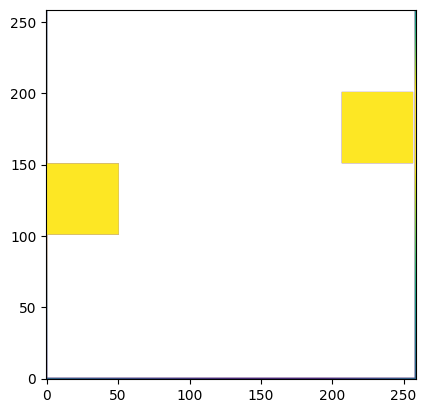

In [7]:
n = 256
bc = DirichletBoundaryCondition.empty_w_size(n+1, n+1)

bc.bottom[:n//2] = torch.linspace(13, 5, n//2)
bc.bottom[n//2:3*n//4] = 5
bc.bottom[3*n//4:] = torch.linspace(5, 13, n//4+1)

bc.top = 21

bc.left[:100] = torch.linspace(13, 40, 100)
bc.left[100:150] = 40
bc.left[150:] = torch.linspace(40, 21, 107)

bc.right[:150] = torch.linspace(13, 40, 150)
bc.right[150:200] = 40
bc.right[200:] = torch.linspace(40, 21, 57)

bc.add_rectangle(50, 50, 40, left=0, bottom=100)
bc.add_rectangle(50, 50, 40, right=-1, top=200)

bc.show()

Runtime: 0.1006s


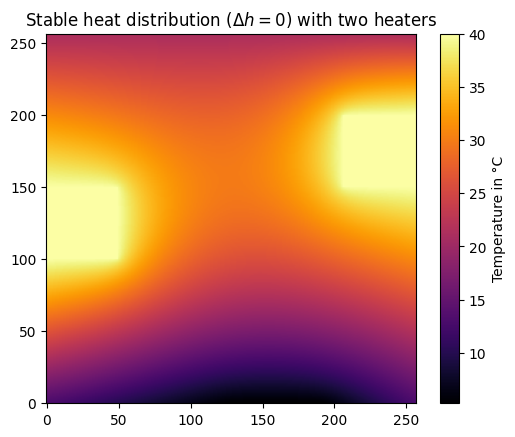

In [22]:
# f_smooth = laplace_full_multigrid_v_cycle(torch.full((257, 257), bc.mean().item()), bc, depth=4, tol=1e-4, maxiter=200)
t1 = time.time()
f_smooth = laplace_multigrid_half_v_cycle(torch.full((257, 257), 22.), bc, depth=4, tol=1e-4, maxiter=200, damping_factor=1.)
t2 = time.time()
print(f'Runtime: {t2 - t1:.4f}s')
plt.imshow(f_smooth, cmap='inferno', origin='lower')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with two heaters')
plt.show()